## Q4 — Goliaths’ impact on Davids
In this file, we examine whether the emissions of the Top 10 “Goliaths” (largest CO₂ emitters) are associated with increasing climate impact on the Top 10 “Davids” (countries with the highest warming metric from Q3).

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
from helpers import is_country

We reuse the Top 10 emitters identified earlier and treat them as “Goliaths” in this analysis:
1. China
2. US
3. Russia
4. Japan
5. Germany
6. India
7. UK
8. Saudi Arabia
9. Iran
10. France

In [122]:
goliaths_iso3 = ["CHN", "USA", "RUS", "JPN", "DEU", "IND", "GBR", "SAU", "IRN", "FRA"]

We load the OWID CO2 dataset, keep only valid countries, and focus on a modern period (from 1990).

In [123]:
df = pd.read_csv("data/owid-co2-data.csv")
df = df[df["iso_code"].apply(lambda x: is_country(x) if isinstance(x, str) else False)].copy()

START_YEAR = 1990
END_YEAR = int(df["year"].max())
df = df[(df["year"] >= START_YEAR) & (df["year"] <= END_YEAR)].copy()

df_goliaths = df[df["iso_code"].isin(goliaths_iso3)].copy()

df_goliaths = df_goliaths[df_goliaths["co2"].notna()].copy()

df_goliaths.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
9899,China,1990,CHN,1.153583e+09,3.385122e+12,83.068,0.072,2483.534,21.384,0.869,...,19.043,7.329,0.024,0.044,0.072,0.003,4205.167,3050.701,-122.764,-4.943
9900,China,1991,CHN,1.170789e+09,3.508948e+12,99.573,0.085,2619.143,135.609,5.460,...,23.957,7.421,0.025,0.046,0.074,0.004,4315.059,3185.453,-161.227,-6.156
9901,China,1992,CHN,1.184574e+09,3.755038e+12,120.352,0.102,2731.290,112.147,4.282,...,23.790,7.516,0.026,0.047,0.076,0.004,4445.956,3302.529,-73.106,-2.677
9902,China,1993,CHN,1.197309e+09,4.126169e+12,140.333,0.117,2914.284,182.994,6.700,...,25.492,7.617,0.026,0.049,0.079,0.004,4591.354,3497.279,-104.192,-3.575
9903,China,1994,CHN,1.209003e+09,4.438753e+12,161.567,0.134,3093.891,179.606,6.163,...,25.425,7.725,0.027,0.050,0.081,0.004,4901.601,3692.746,-301.852,-9.756


We aggregate annual CO2 emissions across all Goliaths to get a single combined emissions time series.

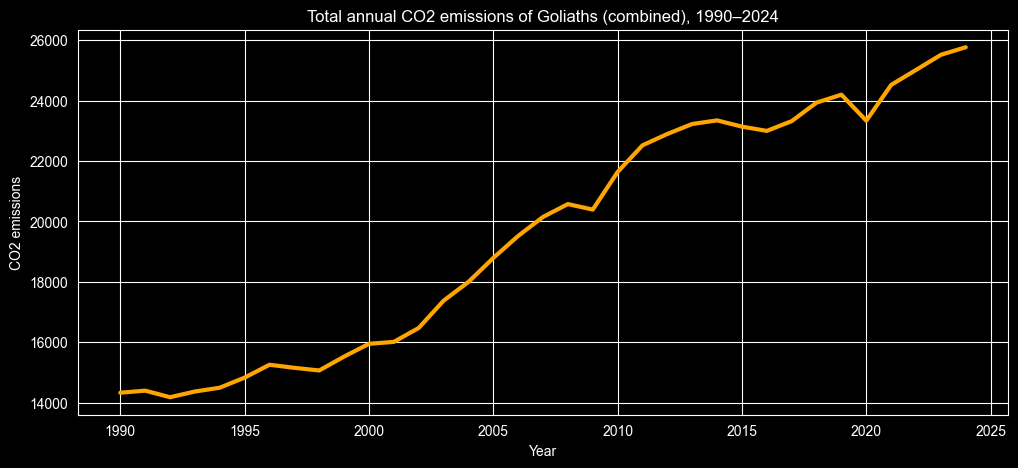

In [124]:
goliaths_total_yearly = (
    df_goliaths.groupby("year", as_index=False)["co2"]
    .sum()
    .rename(columns={"co2": "goliaths_total_co2"})
)

plt.figure(figsize=(12, 5))
plt.plot(
    goliaths_total_yearly["year"],
    goliaths_total_yearly["goliaths_total_co2"],
    linewidth=3,
    color='orange'
)
plt.title(f"Total annual CO2 emissions of Goliaths (combined), {START_YEAR}–{END_YEAR}")
plt.xlabel("Year")
plt.ylabel("CO2 emissions")
plt.show()

**Observation:** The combined annual CO2 emissions of the Top 10 Goliaths show a clear long-term increase from 1990 to 2024. The steepest growth occurs in the 2000s (roughly 2002–2012). A noticeable dip appears around 2020, after which emissions rise again to the highest levels in the series.

We plot CO2 emissions for each Goliath separately to see their individual trends.

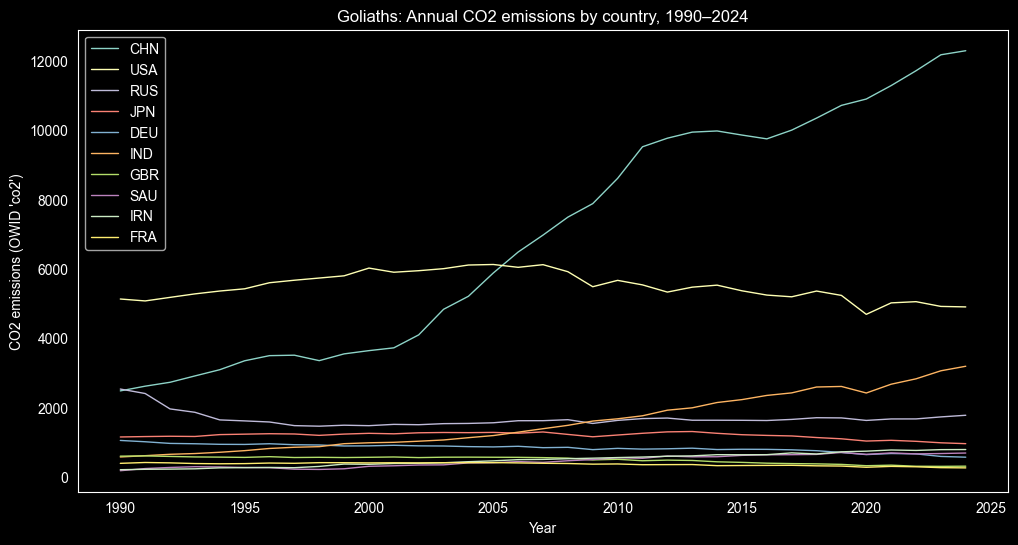

In [125]:
goliaths_by_country_yearly = df_goliaths.pivot_table(
    index="year",
    columns="iso_code",
    values="co2",
    aggfunc="sum"
).reset_index()

plt.figure(figsize=(12, 6))

for code in goliaths_iso3:
    if code in goliaths_by_country_yearly.columns:
        plt.plot(
            goliaths_by_country_yearly["year"], 
            goliaths_by_country_yearly[code], 
            label=code,
            linewidth=1,
        )

plt.title(f"Goliaths: Annual CO2 emissions by country, {START_YEAR}–{END_YEAR}")
plt.xlabel("Year")
plt.ylabel("CO2 emissions (OWID 'co2')")
plt.grid(False)
plt.legend()
plt.show()


**Observation:** The Goliaths do not contribute equally to total emissions. China shows the strongest long-term increase and dominates the overall trend, while the USA remains high but is relatively stable or slightly decreasing in recent years. India shows a clear upward trend, whereas several European countries and Japan are relatively flat or gradually decreasing.

We reuse the Top 10 temperature-impacted countries from Q3 as “Davids” and compute their average temperature-change trend over time:
1. Serbia
2. Luxembourg
3. Montenegro
4. Estonia
5. Belgium
6. Belarus
7. Latvia
8. Russia
9. Slovenia
10. Lithuania

In [126]:
davids_iso3 = ["SRB", "LUX", "MNE", "EST", "BEL", "BLR", "LVA", "RUS", "SVN", "LTU"]

df_temp = pd.read_csv("data/AnnualMeanGlobalSurfaceTemperature.csv")
df_temp = df_temp[df_temp["ISO3"].apply(is_country)].copy()

year_cols = [c for c in df_temp.columns if c.isdigit() and START_YEAR <= int(c) <= END_YEAR]
df_davids = df_temp[df_temp["ISO3"].isin(davids_iso3)].copy()

We compute the yearly average across the Davids group to represent their overall impact as one trend line, which we can directly compare with Goliaths’ combined emissions.

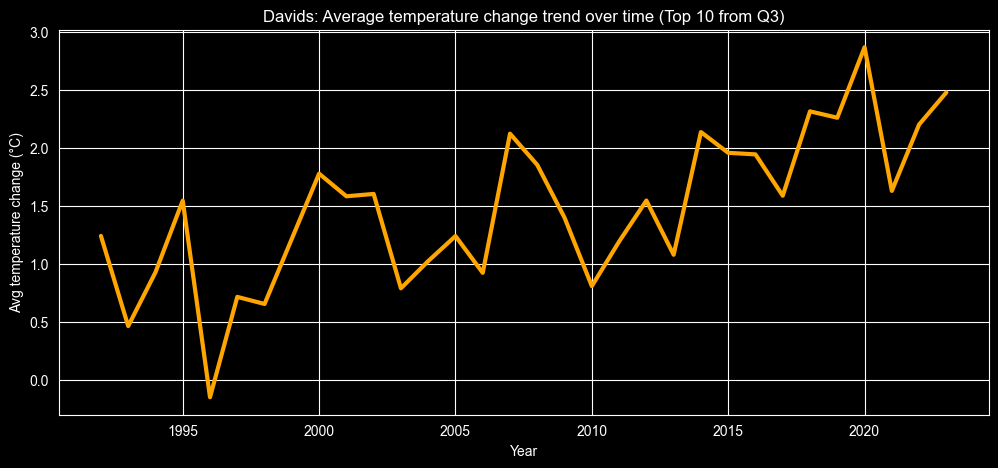

In [127]:
davids_yearly = df_davids[year_cols].mean(axis=0)

df_david_trend = pd.DataFrame({
    "year": [int(y) for y in year_cols],
    "davids_avg_temp_change": davids_yearly.values
}).sort_values("year")

plt.figure(figsize=(12, 5))
plt.plot(
    df_david_trend["year"], 
    df_david_trend["davids_avg_temp_change"], 
    linewidth=3,
    color="orange"
)
plt.title("Davids: Average temperature change trend over time (Top 10 from Q3)")
plt.xlabel("Year")
plt.ylabel("Avg temperature change (°C)")
plt.grid(True)
plt.show()

We merge the two time series by year so both metrics can be compared over the same period.

In [128]:
df_compare = pd.merge(
    goliaths_total_yearly[["year", "goliaths_total_co2"]],
    df_david_trend[["year", "davids_avg_temp_change"]],
    on="year",
    how="inner"
).sort_values("year")

Because CO₂ emissions and temperature change are in different units and scales, we apply min–max normalization to compare their relative trends over time.

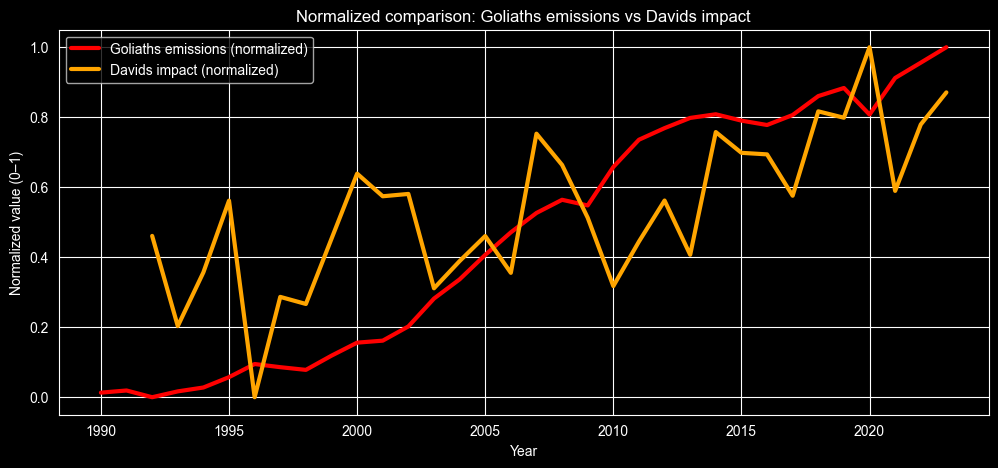

In [129]:
df_norm = df_compare.copy()

df_norm["goliaths_norm"] = (
    (df_norm["goliaths_total_co2"] - df_norm["goliaths_total_co2"].min()) /
    (df_norm["goliaths_total_co2"].max() - df_norm["goliaths_total_co2"].min())
)

df_norm["davids_norm"] = (
    (df_norm["davids_avg_temp_change"] - df_norm["davids_avg_temp_change"].min()) /
    (df_norm["davids_avg_temp_change"].max() - df_norm["davids_avg_temp_change"].min())
)

plt.figure(figsize=(12, 5))
plt.plot(df_norm["year"], df_norm["goliaths_norm"], label="Goliaths emissions (normalized)", linewidth=3, color="red")
plt.plot(df_norm["year"], df_norm["davids_norm"], label="Davids impact (normalized)", linewidth=3, color="orange")
plt.title("Normalized comparison: Goliaths emissions vs Davids impact")
plt.xlabel("Year")
plt.ylabel("Normalized value (0–1)")
plt.grid(True)
plt.legend()
plt.show()

**Observation:** Both normalized series (Goliaths’ emissions and Davids’ impact) trend upward over time, which suggests that rising emissions may be associated with increasing impacts on Davids.

We plot annual observations (combined Goliaths emissions vs Davids’ average temperature change) and add a simple linear fit line to visually inspect the association.

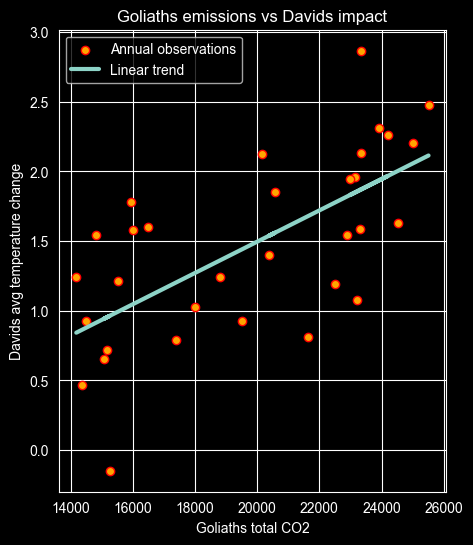

In [130]:
# Linear fit: y = m*x + b
tmp = df_compare[["goliaths_total_co2", "davids_avg_temp_change"]].replace([np.inf, -np.inf], np.nan).dropna()
x = tmp["goliaths_total_co2"].to_numpy()
y = tmp["davids_avg_temp_change"].to_numpy()
m, b = np.polyfit(x, y, 1)
y_fit = m * x + b

plt.figure(figsize=(5, 6))
plt.scatter(
    df_compare["goliaths_total_co2"], 
    df_compare["davids_avg_temp_change"], 
    color="orange", 
    edgecolors="red", 
    label="Annual observations"
)
plt.plot(x, y_fit, linewidth=3, label="Linear trend")
plt.title("Goliaths emissions vs Davids impact")
plt.xlabel("Goliaths total CO2")
plt.ylabel("Davids avg temperature change")
plt.grid(True)
plt.legend()
plt.show()

The upward trend line suggests a positive association, although the relationship is dispersed and not strictly linear.

In [131]:
# Correlation between Goliaths' emissions and Davids' impact over time
tmp = df_compare[["goliaths_total_co2", "davids_avg_temp_change"]].replace([np.inf, -np.inf], np.nan).dropna()

spearman = tmp["goliaths_total_co2"].corr(tmp["davids_avg_temp_change"], method="spearman")
print(f"Spearman: {spearman:.4f}")

Spearman: 0.7053


The spearman correlation (~0.71) indicates a strong positive monotonic association between Goliaths’ emissions and Davids’ impact over time.

The dataset also provides each country’s share of global CO2 (percentage contribution to the world total for a given year). We use this to measure how concentrated global emissions are and to show how much of the world’s CO2 is produced by the Top 10 Goliaths compared to the rest of the world.

In [132]:
# Top 10 Goliaths: combined share of global CO2 over time
df_g_share = df_goliaths[df_goliaths["share_global_co2"].notna()].copy()

goliaths_share_yearly = (
    df_g_share.groupby("year", as_index=False)["share_global_co2"]
    .sum()
)

goliaths_share_yearly.head()

,year,share_global_co2
0,1990,63.035
1,1991,62.046
2,1992,62.968
3,1993,63.164
4,1994,63.092


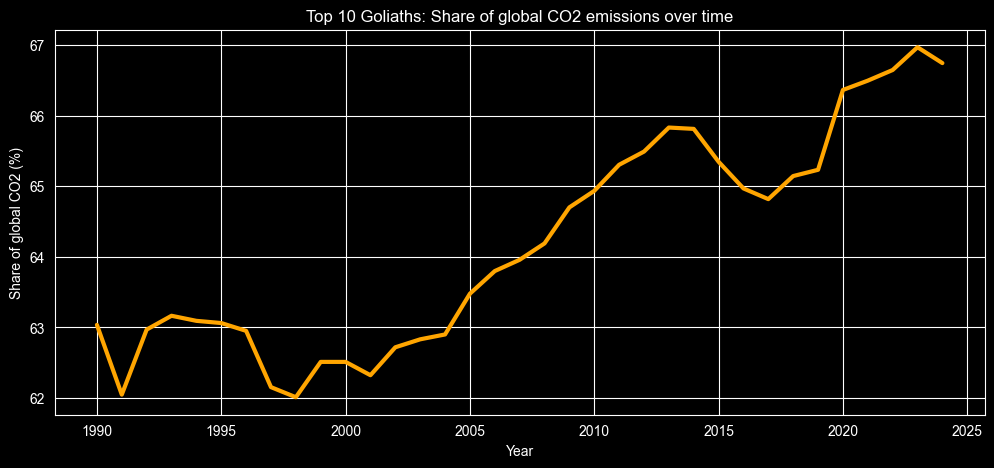

In [133]:
plt.figure(figsize=(12, 5))
plt.plot(
    goliaths_share_yearly["year"],
    goliaths_share_yearly["share_global_co2"],
    linewidth=3,
    color="orange"
)
plt.title("Top 10 Goliaths: Share of global CO2 emissions over time")
plt.xlabel("Year")
plt.ylabel("Share of global CO2 (%)")
plt.grid(True)
plt.show()

*Observation:* The Top 10 Goliaths consistently account for the majority of global CO₂ emissions (roughly 62–67% across the period).

To understand what drives the combined share, we also plot each Goliath’s share separately.

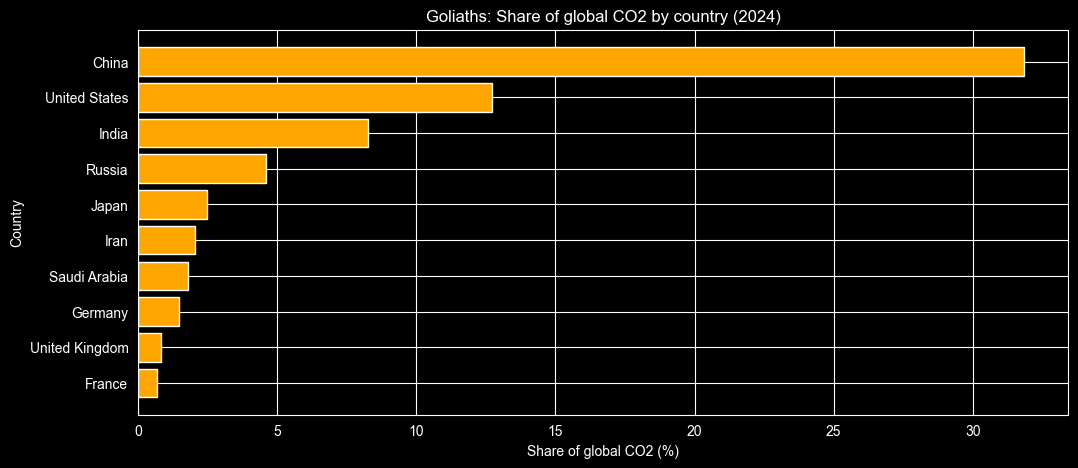

In [134]:
latest_year = int(goliaths_share_yearly["year"].max())

df_latest = df_g_share[df_g_share["year"] == latest_year][["country", "iso_code", "share_global_co2"]].copy()
df_latest = df_latest.sort_values("share_global_co2", ascending=False)

plt.figure(figsize=(12, 5))
plt.barh(df_latest["country"][::-1], df_latest["share_global_co2"][::-1], color="orange")
plt.title(f"Goliaths: Share of global CO2 by country ({latest_year})")
plt.xlabel("Share of global CO2 (%)")
plt.ylabel("Country")
plt.grid(True, axis="x")
plt.show()
# In the latest year, contributions within the Top 10 are highly uneven, China and the United States account for the largest shares

Even within the Goliaths group, contributions are uneven: a few countries (China, USA and India) drive most of the combined share, while others have comparatively minor shares.